## Time Series Data Analysis
### Import Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [29]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import month_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [7]:
co2_weekly = sm.datasets.co2.load_pandas().data
co2_monthly = co2_weekly["co2"].resample("M").mean()
co2_series = co2_monthly.interpolate()

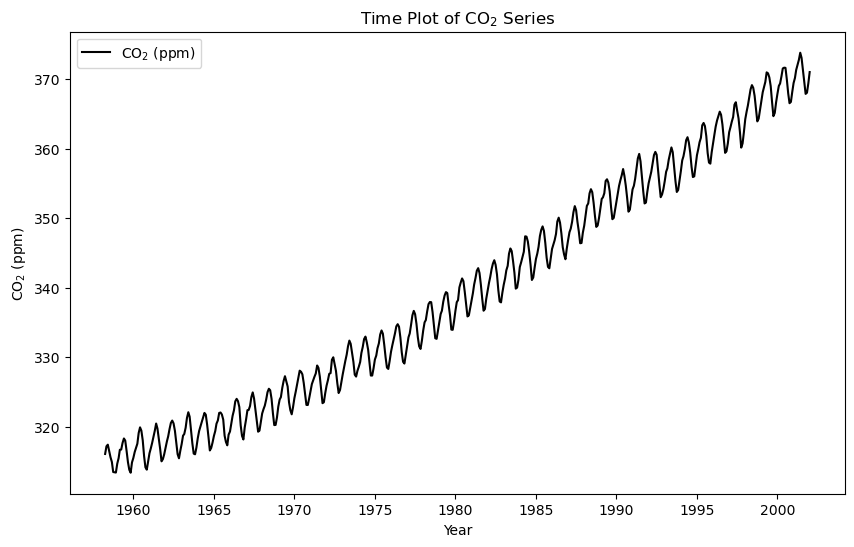

In [9]:
# Time Plot
plt.figure(figsize=(10,6))
plt.plot(co2_series, label="CO$_2$ (ppm)", color="black")
plt.title("Time Plot of CO$_2$ Series")
plt.xlabel("Year")
plt.ylabel("CO$_2$ (ppm)")
plt.legend()
plt.show()

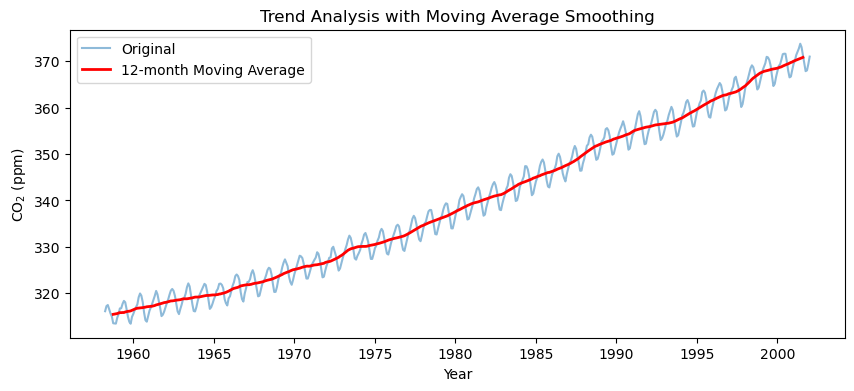

In [10]:
# Trend Analysis
rolling_mean = co2_series.rolling(window=12, center=True).mean()
plt.figure(figsize=(10,4))
plt.plot(co2_series, label="Original", alpha=0.5)
plt.plot(rolling_mean, label="12-month Moving Average", color="red", linewidth=2)
plt.title("Trend Analysis with Moving Average Smoothing")
plt.xlabel("Year")
plt.ylabel("CO$_2$ (ppm)")
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

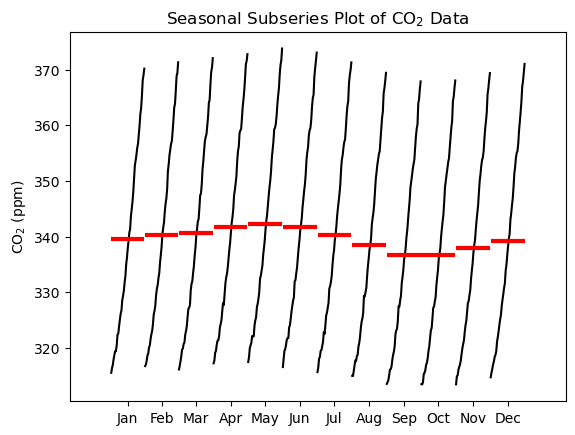

In [13]:
# Seasonal Plots - Subseries Plots
plt.figure(figsize=(8,6))
month_plot(co2_series)
plt.title("Seasonal Subseries Plot of CO$_2$ Data")
plt.ylabel("CO$_2$ (ppm)")
plt.show()

/Applications/anaconda3/envs/cmpinf2120/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 800x500 with 0 Axes>

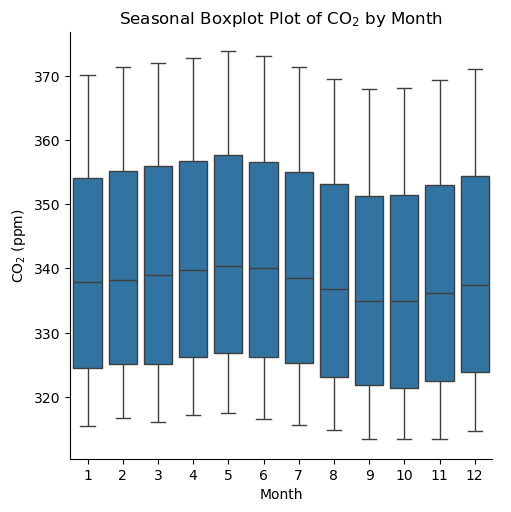

In [24]:
# Seasonal Boxplot
data = pd.DataFrame({"month": co2_series.index.month, "co2":co2_series.values})
plt.figure(figsize=(8,5))
sns.catplot(data=data, x="month", y="co2", kind="box")
plt.title("Seasonal Boxplot Plot of CO$_2$ by Month")
plt.xlabel("Month")
plt.ylabel("CO$_2$ (ppm)")
plt.show()

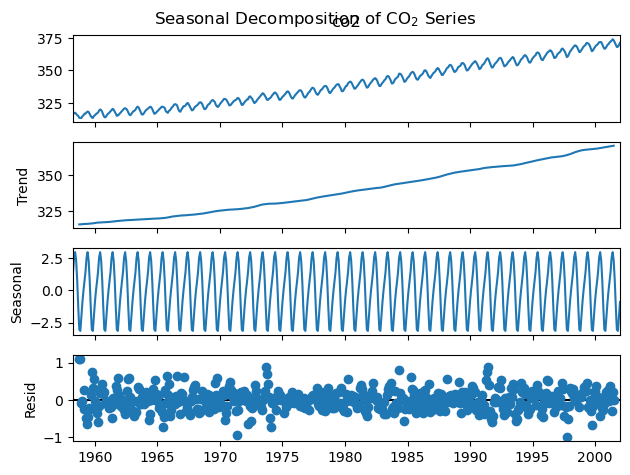

In [26]:
# Seasonal Decomposition
decomp_result = seasonal_decompose(co2_series, model="additive", period=12)
decomp_result.plot()
plt.suptitle("Seasonal Decomposition of CO$_2$ Series", fontsize=12)
plt.show()

<Figure size 800x400 with 0 Axes>

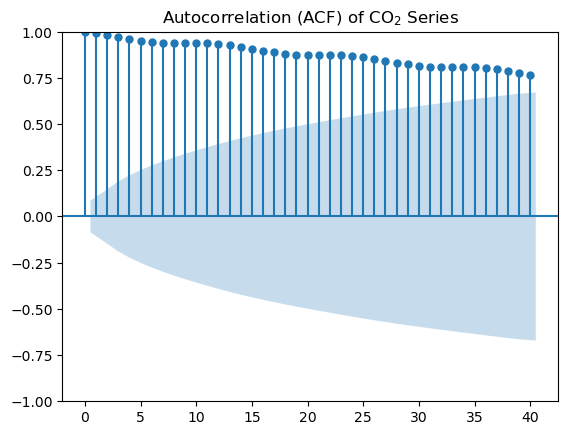

In [28]:
# Autocorrelation Function
plt.figure(figsize=(8,4))
plot_acf(co2_series, lags=40)
plt.title("Autocorrelation (ACF) of CO$_2$ Series")
plt.show()

<Figure size 800x400 with 0 Axes>

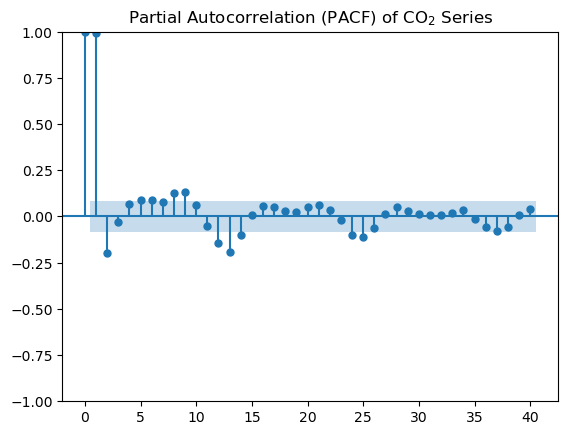

In [30]:
# Partial Autocorrelation Function (PACF)
plt.figure(figsize=(8,4))
plot_pacf(co2_series, lags=40, method="ywm")
plt.title("Partial Autocorrelation (PACF) of CO$_2$ Series")
plt.show()

In [32]:
# Testing for Stationarity using Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller
adf_stat, adf_pvalue, _, _, _, _ = adfuller(co2_series.dropna())
print(f"ADF Test Statistic: {adf_stat: 3f}")
print(f"ADF p-value: {adf_pvalue: 3f}")

ADF Test Statistic:  2.232835
ADF p-value:  0.998908


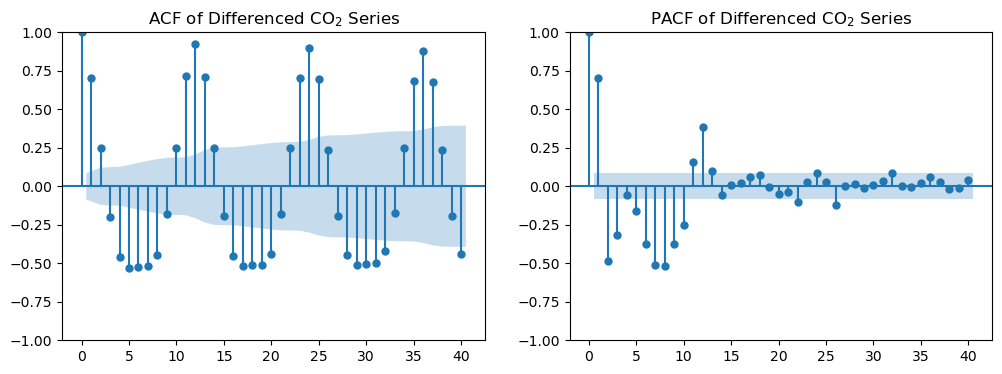

In [43]:
# Differencing
co2_diff = co2_series.diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(co2_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF of Differenced CO$_2$ Series")
plot_pacf(co2_diff, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Differenced CO$_2$ Series")
plt.show()

In [44]:
adf_stat_dff, adf_pvalue_diff, _,_,_,_ = adfuller(co2_diff)
print(f"ADF p-value after differencing: {adf_pvalue_diff: .3f}")

ADF p-value after differencing:  0.000


In [46]:
# Detecting outliers
ts = co2_series.copy()

outlier_date = "1975-05-31"
ts[outlier_date] = ts[outlier_date] + 100

mean_ts = ts.mean()
std_ts = ts.std()
upper_bound = mean_ts + 3*std_ts
lower_bound = mean_ts - 3*std_ts

outliers = ts[(ts > upper_bound) | (ts < lower_bound)]

print("Detected outlier(s):")
print(outliers)

Detected outlier(s):
1975-05-31    433.86
Freq: M, Name: co2, dtype: float64


In [56]:
if not outliers.empty:
        for date in outliers.index:
            print("Outlier on", date)
            print("Old value:", ts[date])
            ts[date] = 0.5 * ts[date - pd.DateOffset(months=1)] + 0.5 * ts[date + pd.DateOffset(months=1)]
            print("New value:", ts[date])

Outlier on 1975-05-31 00:00:00
Old value: 333.3375
New value: 333.3375


In [58]:
# Missing data
ts_with_nan = ts.copy()
missing_date="1980-01-31"
ts_with_nan[missing_date] = np.nan

missing_indices = ts_with_nan[ts_with_nan.isna()].index
print("Missing data at:", missing_indices)

Missing data at: DatetimeIndex(['1980-01-31'], dtype='datetime64[ns]', freq='M')


In [59]:
ts_filled = ts_with_nan.interpolate()

In [61]:
ts_filled[missing_date]

337.4425

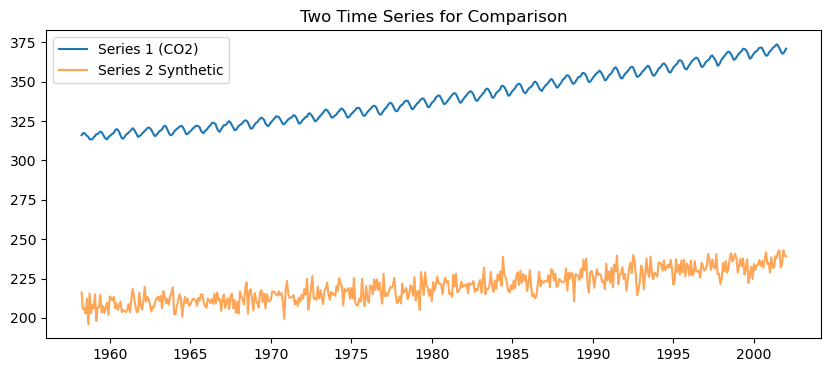

In [63]:
# Pearson Correlation Coefficient
np.random.seed(1)
series1 = ts_filled
series2 = 0.5*series1 + 50 + np.random.normal(scale=5.0, size=len(series1))

plt.figure(figsize=(10,4))
plt.plot(series1, label="Series 1 (CO2)")
plt.plot(series2, label="Series 2 Synthetic", alpha=0.7)
plt.title("Two Time Series for Comparison")
plt.legend()
plt.show()

In [64]:
from scipy.stats import pearsonr

r, p_val = pearsonr(series1, series2)
print(f"Pearson correlation r = {r:.3f} with p-value = {p_val:.3f}")

Pearson correlation r = 0.865 with p-value = 0.000


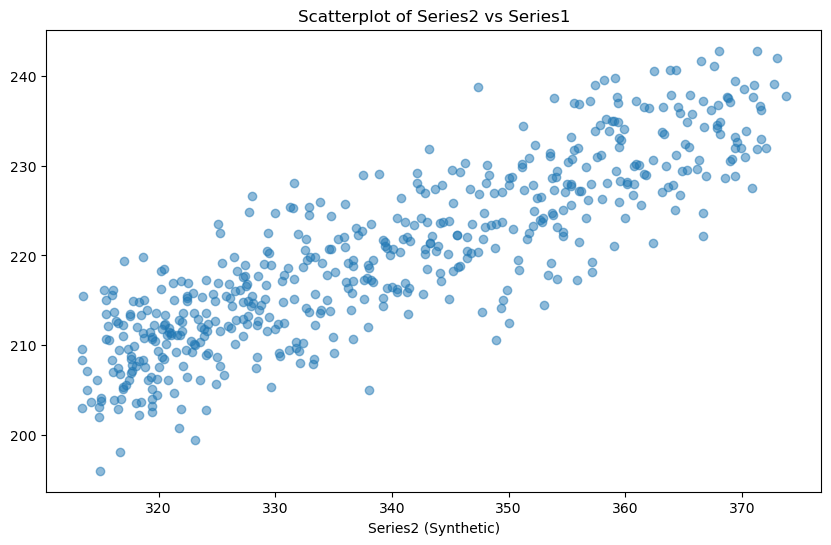

In [66]:
plt.figure(figsize=(10,6))
plt.scatter(series1, series2, alpha=0.5)
# plt.plot(series1, label="Series 1 (CO2)")
# plt.plot(series2, label="Series 2 Synthetic", alpha=0.7)
plt.title("Scatterplot of Series2 vs Series1")
plt.xlabel("Series1 (CO2)")
plt.xlabel("Series2 (Synthetic)")
plt.show()

In [88]:
# Moving Average (MA) Model
from statsmodels.tsa.arima.model import ARIMA

np.random.seed(42)
n = 200

In [89]:
theta1 = 0.8
eps1 = np.random.normal(0,1, n+1)

y_ma1 = [eps1[t+1] + theta1 * eps1[t] for t in range(n)]

y_ma1 = pd.Series(y_ma1)

In [90]:
theta1_ma2, theta2_ma2 = 0.5, -0.4
eps2 = np.random.normal(0,1, n+2)

y_ma2 = [eps2[t+2] + theta1_ma2 * eps2[t+1] + theta2_ma2 * eps2[t] for t in range(n)]

y_ma2 = pd.Series(y_ma2)

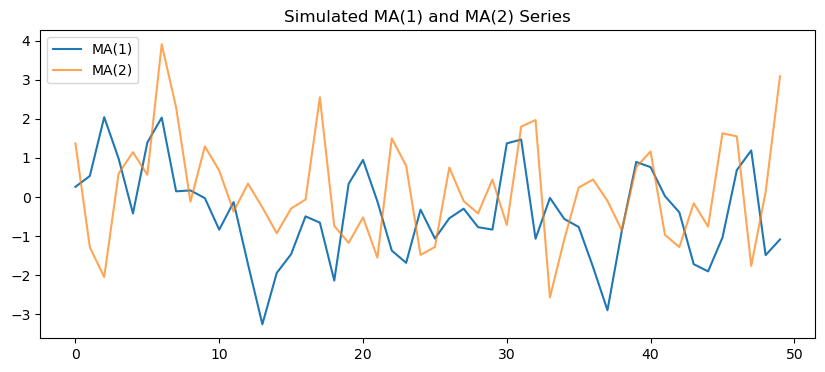

In [92]:
plt.figure(figsize=(10,4))
plt.plot(y_ma1[:50], label="MA(1)")
plt.plot(y_ma2[:50], label="MA(2)", alpha=0.7)
plt.title("Simulated MA(1) and MA(2) Series")
plt.legend()
plt.show()

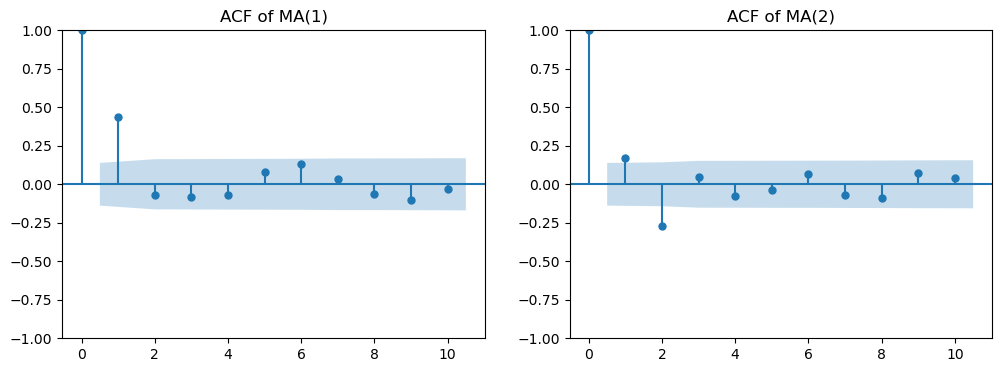

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(y_ma1, lags=10, ax=axes[0])
axes[0].set_title("ACF of MA(1)")
plot_acf(y_ma2, lags=10, ax=axes[1])
axes[1].set_title("ACF of MA(2)")
plt.show()

In [96]:
for lag in range(1, 6):
    corr = np.corrcoef(y_ma2[lag:], y_ma2[:-lag])[0,1]
    print(f"Lag {lag} autocorrelation (MA(2)): {corr:.3f}")

Lag 1 autocorrelation (MA(2)): 0.173
Lag 2 autocorrelation (MA(2)): -0.272
Lag 3 autocorrelation (MA(2)): 0.048
Lag 4 autocorrelation (MA(2)): -0.076
Lag 5 autocorrelation (MA(2)): -0.037


In [98]:
# Fitting MA Models
model_ma1 = ARIMA(y_ma1, order=(0, 0, 1))
result_ma1 = model_ma1.fit()
print(result_ma1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -269.121
Date:                Sun, 03 Aug 2025   AIC                            544.243
Time:                        22:20:43   BIC                            554.138
Sample:                             0   HQIC                           548.247
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0701      0.122     -0.576      0.565      -0.309       0.169
ma.L1          0.8463      0.038     22.514      0.000       0.773       0.920
sigma2         0.8581      0.086     10.035      0.0

In [99]:
model_ma2 = ARIMA(y_ma2, order=(0, 0, 2))
result_ma2 = model_ma2.fit()
print(result_ma2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -282.104
Date:                Sun, 03 Aug 2025   AIC                            572.207
Time:                        22:27:33   BIC                            585.401
Sample:                             0   HQIC                           577.547
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0729      0.073      1.005      0.315      -0.069       0.215
ma.L1          0.4525      0.063      7.144      0.000       0.328       0.577
ma.L2         -0.4278      0.067     -6.369      0.0

In [100]:
# Autoregressive (AR) Models
np.random.seed(123)
n = 200

phi1 = 0.6
y_ar1 = np.zeros(n)
eps_ar1 = np.random.normal(0, 1, n)
for t in range(1, n):
    y_ar1[t] = phi1*y_ar1[t-1] + eps_ar1[t]

phi1_ar2 = 0.5
phi2_ar2 = -0.3
y_ar2 = np.zeros(n)
eps_ar2 = np.random.normal(0, 1, n)

for t in range(2, n):
    y_ar2[t] = phi1_ar2*y_ar2[t-1] + phi2_ar2*y_ar2[t-2] + eps_ar2[t]

y_ar1 = pd.Series(y_ar1)
y_ar2 = pd.Series(y_ar2)

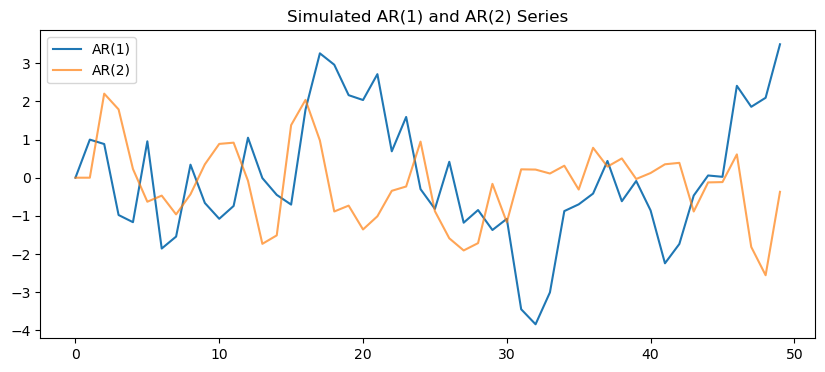

In [102]:
plt.figure(figsize=(10,4))
plt.plot(y_ar1[:50], label="AR(1)")
plt.plot(y_ar2[:50], label="AR(2)", alpha=0.7)
plt.title("Simulated AR(1) and AR(2) Series")
plt.legend()
plt.show()

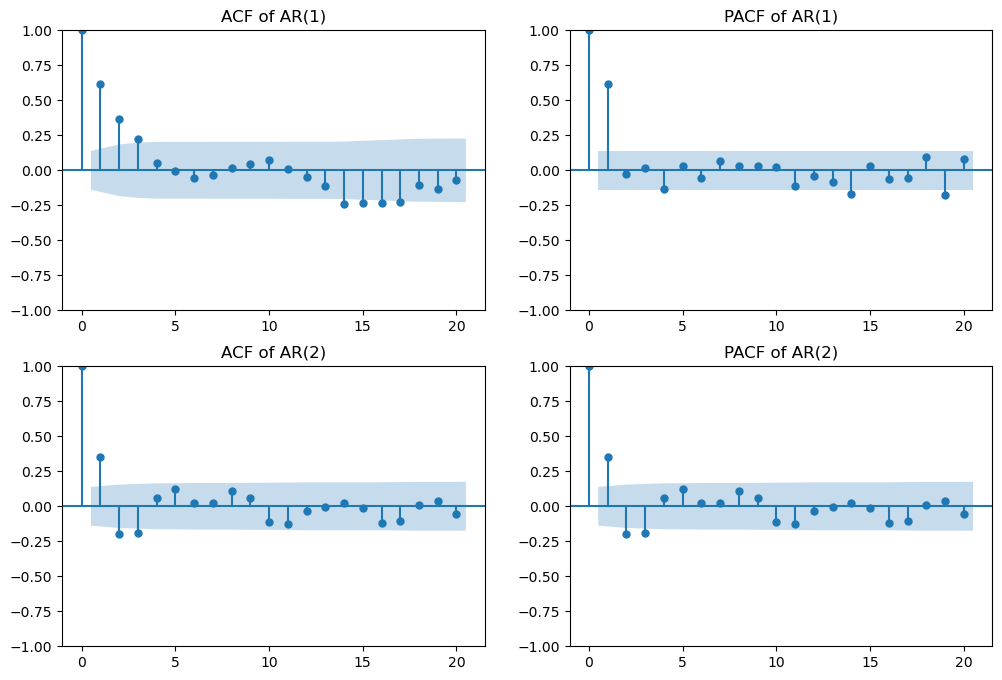

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
plot_acf(y_ar1, lags=20, ax=axes[0, 0])
axes[0, 0].set_title("ACF of AR(1)")
plot_acf(y_ar2, lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF of AR(2)")

plot_pacf(y_ar1, lags=20, ax=axes[0, 1])
axes[0, 1].set_title("PACF of AR(1)")
plot_acf(y_ar2, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("PACF of AR(2)")
plt.show()

In [110]:
model_ar1 = ARIMA(y_ar1, order=(1, 0, 0))
result_ar1 = model_ar1.fit()
print(result_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -293.634
Date:                Sun, 03 Aug 2025   AIC                            593.269
Time:                        22:50:21   BIC                            603.164
Sample:                             0   HQIC                           597.273
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0222      0.194      0.114      0.909      -0.359       0.403
ar.L1          0.6171      0.059     10.507      0.000       0.502       0.732
sigma2         1.1008      0.110     10.035      0.0

In [113]:
model_ar2 = ARIMA(y_ar2, order=(2,0,0)).fit()
print(model_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -267.306
Date:                Sun, 03 Aug 2025   AIC                            542.612
Time:                        22:51:35   BIC                            555.806
Sample:                             0   HQIC                           547.952
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1442      0.075     -1.935      0.053      -0.290       0.002
ar.L1          0.4789      0.073      6.534      0.000       0.335       0.623
ar.L2         -0.3643      0.066     -5.487      0.0

In [118]:
# ARIMA Models
## D = 1 (AR(1))
np.random.seed(202)
n = 300
phi = 0.5
eps = np.random.normal(0, 1, n)
diff = np.zeros(n)
for t in range(1, n):
    diff[t] = phi*diff[t-1] + eps[t]

y_arima110 = np.cumsum(diff)
y_arima110 = pd.Series(y_arima110)

In [119]:
adfuller(y_arima110)[1]

0.8765321659492563

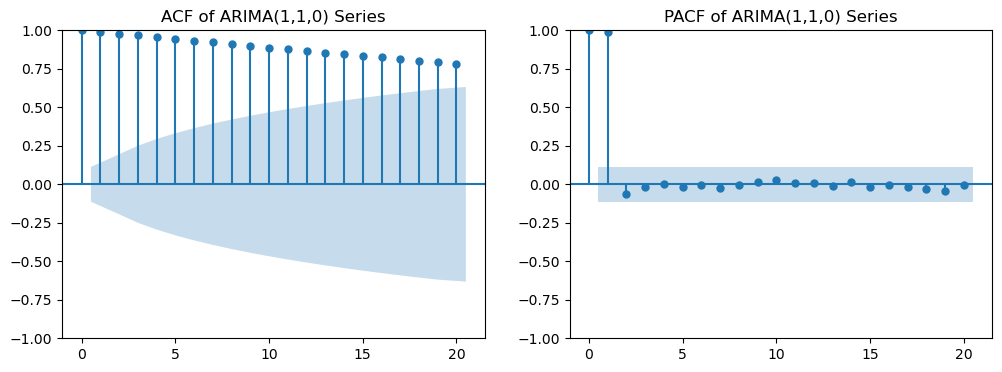

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(y_arima110, lags=20, ax=axes[0])
axes[0].set_title("ACF of ARIMA(1,1,0) Series")
plot_pacf(y_arima110, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of ARIMA(1,1,0) Series")
plt.show()

In [126]:
# Now, with first differencing
y_arima110_diff = y_arima110.diff().dropna()
print("ADF p-value after first differencing:",adfuller(y_arima110_diff)[1])

ADF p-value after first differencing: 4.255704826676432e-17


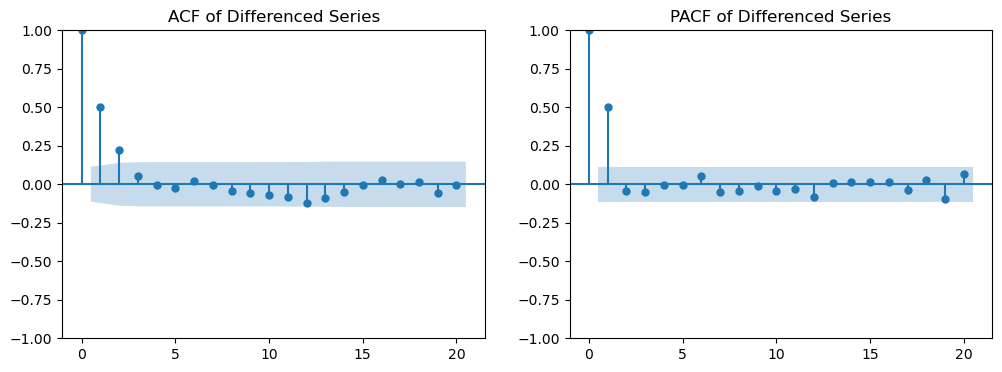

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(y_arima110_diff, lags=20, ax=axes[0])
axes[0].set_title("ACF of Differenced Series")
plot_pacf(y_arima110_diff, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Differenced Series")
plt.show()

In [129]:
# Fit the model
model = ARIMA(y_arima110, order=(1,1,0))
res = model.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -413.418
Date:                Sun, 03 Aug 2025   AIC                            830.836
Time:                        23:10:25   BIC                            838.237
Sample:                             0   HQIC                           833.798
                                - 300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5191      0.048     10.735      0.000       0.424       0.614
sigma2         0.9290      0.084     11.121      0.000       0.765       1.093
Ljung-Box (L1) (Q):                   0.01   Jarque-

<Figure size 600x400 with 0 Axes>

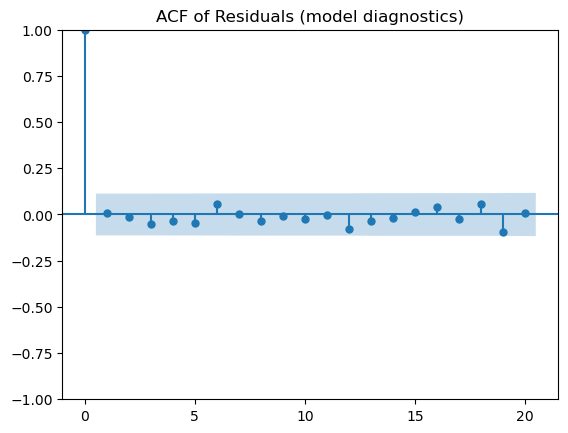

In [132]:
# Residual Diagnostics
residuals = res.resid

plt.figure(figsize=(6,4))
plot_acf(residuals, lags=20)
plt.title("ACF of Residuals (model diagnostics)")
plt.show()

In [133]:
# Model with d=0

In [134]:
model = ARIMA(y_ma1, order=(0, 0,1))
res = model.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -269.121
Date:                Sun, 03 Aug 2025   AIC                            544.243
Time:                        23:12:47   BIC                            554.138
Sample:                             0   HQIC                           548.247
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0701      0.122     -0.576      0.565      -0.309       0.169
ma.L1          0.8463      0.038     22.514      0.000       0.773       0.920
sigma2         0.8581      0.086     10.035      0.0

<Figure size 600x400 with 0 Axes>

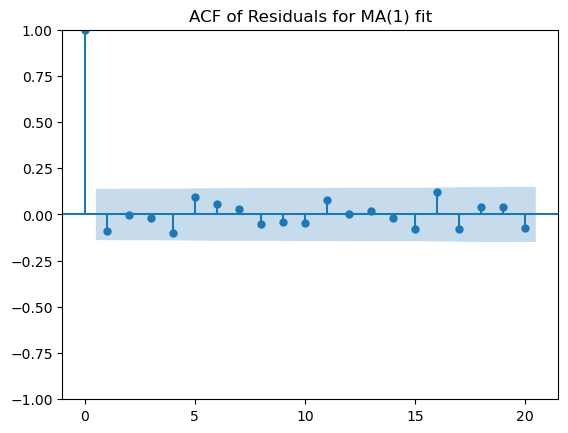

In [135]:
plt.figure(figsize=(6,4))
plot_acf(res.resid, lags=20)
plt.title("ACF of Residuals for MA(1) fit")
plt.show()

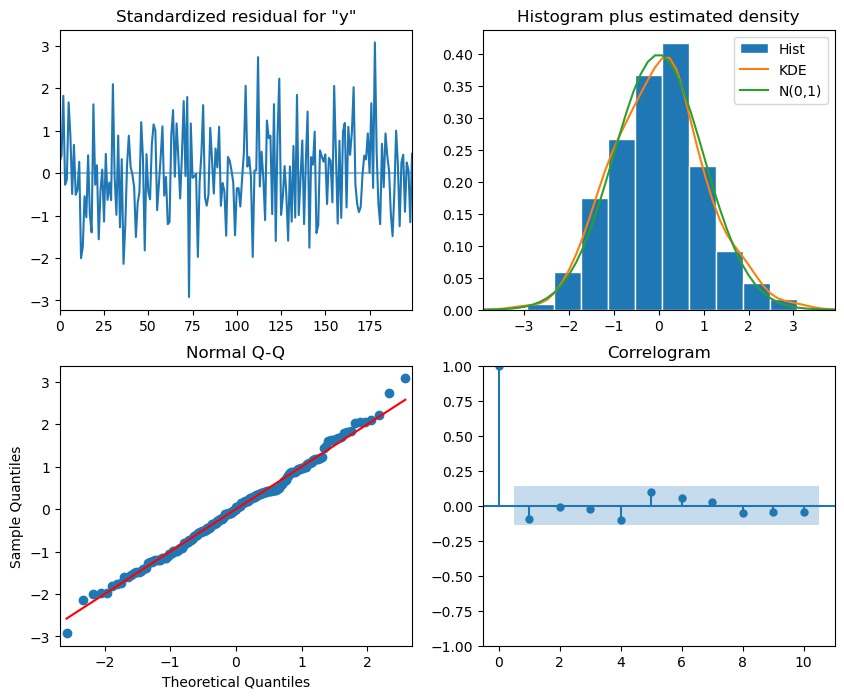

In [136]:
res.plot_diagnostics(figsize=(10,8))
plt.show()

In [138]:
# ARIMA(0,1,1)
theta = 0.6
eps = np.random.normal(0, 1, n+1)
diff_ma = np.zeros(n+1)
for t in range(1, n+1):
    diff_ma[t] = eps[t] + theta * eps[t-1]
y_arima011 = np.cumsum(diff_ma)
y_arima011 = pd.Series(y_arima011)

In [140]:
model = ARIMA(y_arima011, order=(0,1,1)).fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  301
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -428.505
Date:                Sun, 03 Aug 2025   AIC                            861.009
Time:                        23:21:44   BIC                            868.417
Sample:                             0   HQIC                           863.974
                                - 301                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.6626      0.046     14.417      0.000       0.573       0.753
sigma2         1.0170      0.090     11.323      0.000       0.841       1.193
Ljung-Box (L1) (Q):                   0.68   Jarque-

In [141]:
# Model Evaluation and Forecasting
train_size = int(len(y_arima110)*0.9)
train, test = y_arima110.iloc[:train_size], y_arima110.iloc[train_size:]

In [144]:
model = ARIMA(train, order=(20,1,1))
res = model.fit()

forecast = res.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)

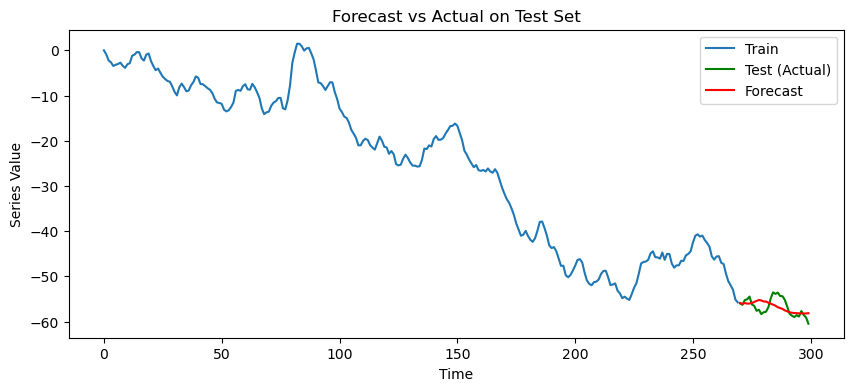

In [148]:
plt.figure(figsize=(10,4))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test (Actual)", color="green")
plt.plot(test.index, forecast, label="Forecast", color="red")
plt.title("Forecast vs Actual on Test Set")
plt.xlabel("Time")
plt.ylabel("Series Value")
plt.legend()
plt.show()

In [152]:
test_vals = test.values
forecast_vals = forecast.values

MAE = np.mean(np.abs(test_vals - forecast_vals))
MSE = np.mean((test_vals - forecast_vals)**2)
RMSE = np.sqrt(MSE)
MAPE = 100*np.mean(np.abs((test_vals - forecast_vals)/test_vals))

print(f"MAE: {MAE:.3f}")
print(f"MSE: {MSE:.3f}")
print(f"RMSE: {RMSE:.3f}")
print(f"MAPE: {MAPE:.3f}%")

MAE: 1.446
MSE: 3.045
RMSE: 1.745
MAPE: 2.572%


<Figure size 640x480 with 0 Axes>

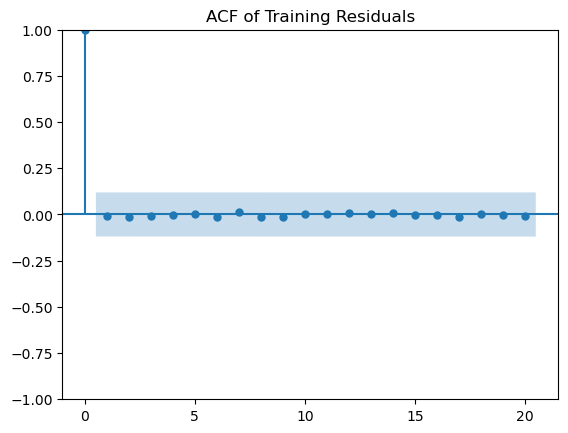

In [153]:
train_resid = res.resid
plt.figure()
plot_acf(train_resid, lags=20)
plt.title("ACF of Training Residuals")
plt.show()

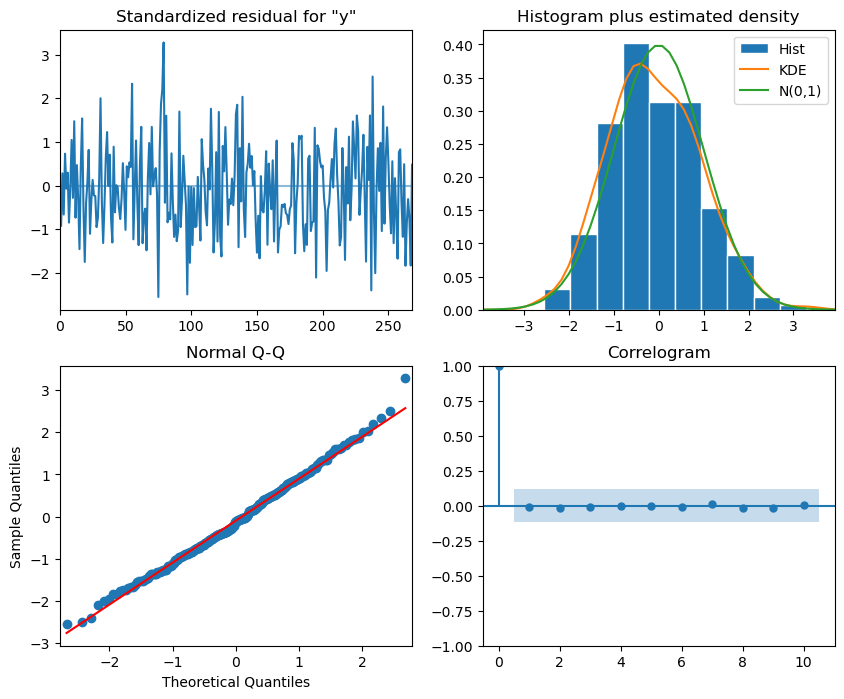

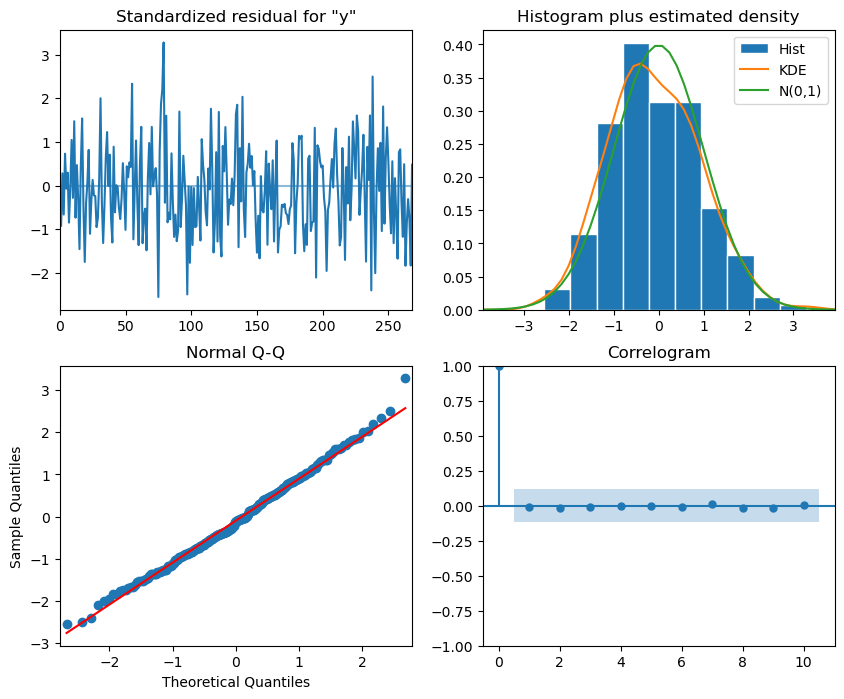

In [157]:
res.plot_diagnostics(figsize=(10,8))